In [1]:
try:
    import smolgp
except ImportError:
    %pip install -q smolgp

try:
    import tinygp
except ImportError:
    %pip install -q tinygp

import jax
import jax.numpy as jnp
import matplotlib as mpl
import matplotlib.pyplot as plt

key = jax.random.PRNGKey(0)
jax.config.update("jax_enable_x64", True)
mpl.rc('font', family='sans serif', size=16)

(multicomponent)=

# Multicomponent Kernels

Many real-life datasets measure not just a single stochastic process but a mixture of multiple processes. With GPs, sums and products of GP kernels are also GP kernels, and so we can construct very flexible models by adding or multiplying GP kernels together to model our signal of interest. For example, a short-timescale SHO (to capture asteroseismic oscillations) with a long-timescale quasiperiodic kernel (to capture rotationally modulated starspot activity).

We use the same model-building framework as `tinygp` described in their tutorial [Mixture of Kernels](https://tinygp.readthedocs.io/en/latest/tutorials/mixture.html), though the state space definition actually enables more user-friendly extraction of individual component posteriors. This is because, for sums of kernels, we model each process independently by stacking their observation matrices together, meaning we can easily extract a single component by projecting through that component's observation matrix. Products of kernels don't decompose like this (the product of two GPs is a GP but that GP's mean is _not_ the product of the means of the two individual GPs; see Ch. 9.6 in [Rasmussen & Williams (2006)](https://gaussianprocess.org/gpml/chapters/RW9.pdf)). 

Appendix C in [Rubenzahl et al. (2026)](https://arxiv.org/abs/2601.02527) summarizes the mathematical procedure for summing or multiplying SSMs. In `smolgp`, it is as easy as using the `+` and `*` operators in Python.


## Example product: the quasiperiodic kernel

A nice example of a product of two `smolgp` kernels is the quasiperiodic kernel, which we define here as the product between an exponential kernel and a periodic kernel:

\begin{align}
        k(\Delta) = \sigma^2\,\exp\left(-\frac{\Delta}{\ell}\right) \exp\left(-\Gamma\,\sin^2(\frac{\pi \Delta}{P}) \right)
\end{align}

where $\sigma$ is the amplitude of the process (`sigma`), $\ell$ is the `scale` parameter of the exponential term (the decay timescale), `P` is the `period` of the periodic term, and $\Gamma$ is the periodic term's smoothness (`gamma`), sometimes also given in terms of the periodic complexity $\eta =  1/\sqrt{2\Gamma}$.

In [2]:
from tinygp.helpers import JAXArray

@tinygp.helpers.dataclass
class Quasiperiodic(smolgp.kernels.Wrapper):

    kernel: smolgp.kernels.StateSpaceModel
    sigma: float | JAXArray
    period: float | JAXArray
    gamma: float | JAXArray
    scale: float | JAXArray

    def __init__(self, period, gamma, scale, sigma, name=None):
        self.period = period
        self.gamma = gamma
        self.scale = scale
        self.sigma = sigma

        # Quasiperiodic is the product of Exp and ExpSineSquared
        # Set sigma=1 for the periodic component so we don't double count it
        Periodic = smolgp.kernels.ExpSineSquared(period=period, gamma=gamma, sigma=1.0)
        Exp = smolgp.kernels.Exp(sigma=sigma, scale=scale)
        self.kernel = Exp * Periodic

        self.name = 'Quasiperiodic' if name is None else name

For our example, let's use the case of apparent radial velocity variations on the Sun from rotationally modulated sunspots. This is well modeled by a quasiperiodic kernel where the period is the rotation period of the Sun and the exponential decay term represents the typical sunspot lifetime.

In [ ]:
# Solar RV hyperparameters from Langellier et al. (2021)
day = 86400 # sec
sigma = 1.44 # m/s (amplitude of RV variations)
period = 28.1 * day # rotation period of the Sun
eta = 0.58
gamma = 1/(2*eta**2)
scale = 23.6 * day # ~spot lifetime
qp_kernel = Quasiperiodic(sigma=sigma, period=period, gamma=gamma, scale=scale)

## Plot the covariance function
fig, ax = plt.subplots(1,1, figsize=(10,4))
dts = jnp.linspace(0, 100, 500) * day
zeros = jnp.zeros_like(dts)
cov = qp_kernel(zeros, dts)[0,:]
ax.plot(dts/day, cov, color='k', lw=3)
ax.set_title('Quasiperiodic kernel');
ax.set(xlabel=r'$\Delta$ [days]', ylabel=r'$k(\Delta)$ [m$^2$/s$^2$]');

## Example sum: fast SHO + slow SHO(s)

Following our example of solar RV variability, let's model the intra-day variability of a solar RV timeseries as a fast SHO (p-mode oscillations) along with two (slower) SHOs with fixed quality factor of $\frac{1}{\sqrt{2}}$ (Harvey-like granulation). 

Here we can also demonstrate the `name` attribute of a `smolgp` kernel. Because all models here are `smolgp.kernels.SHO`, they will automatically be assigned names of `SHO1`, `SHO2`, etc. by the GP object when we create it. Alternatively, we can give them more descriptive names at construction:

In [ ]:
# Solar oscillation hyperparameters from Gupta & Bedell 2024
S_osc=2.36    # m^2/rad/s  
w_osc=0.0195  # rad/s   
Q_osc=7.63    # dimensionless
sig_osc = jnp.sqrt(S_osc * w_osc * Q_osc)
osc_kernel = smolgp.kernels.SHO(sigma=sig_osc, omega=w_osc, quality=Q_osc, name='Oscillation')

# Solar granulation hyperparameters from O'Sullivan et al. 2025
Q_gran = 1/jnp.sqrt(2.)
rho_gran = 0.031 * day  # sec
sig_gran = 0.329  # m/s
w_gran = 2 * jnp.pi / rho_gran
S_gran = sig_gran**2  / (w_gran * Q_gran)
gran_kernel = smolgp.kernels.SHO(sigma=sig_gran, omega=w_gran, quality=Q_gran, name='Granulation')

# Solar supergranulation hyperparameters from O'Sullivan et al. 2025
Q_sgran = 1/jnp.sqrt(2.)
rho_sgran = 1.053 * day  # sec
sig_sgran = 0.752  # m/s
w_sgran = 2 * jnp.pi / rho_sgran
S_sgran = sig_sgran**2  / (w_sgran * Q_sgran)
sgran_kernel = smolgp.kernels.SHO(sigma=sig_sgran, omega=w_sgran, quality=Q_sgran, name='Supergranulation')

# Add together
kernel = osc_kernel + gran_kernel + sgran_kernel

The `extract_leaf_kernels` function can be used to return all component kernels in a multicomponent model. By default, the function will only decompose sums (valid for extracting per-component distributions). If for some reason you want all components (i.e. decompose sums _and_ products), set `all=True`.

In [ ]:
from smolgp.kernels.base import extract_leaf_kernels

ks = extract_leaf_kernels(kernel)
for k in ks:
    print(k.name)

Oscillation
Granulation
Supergranulation


Note that a `Wrapper` object, e.g. the `Quasiperiodic` kernel defined above, cannot be further decomposed even if `all=True`. This is conveneint for defining multicomponent kernels we would not want to decompose anyway. We'd have to extract with `all=True` on the `.kernel` attribute of a `Wrapper` object to see what components went into defining it:

In [ ]:
for k in extract_leaf_kernels(qp_kernel.kernel, all=True):
    print(k.name)

Exp
ExpSineSquared


Let's plot the covariance function and PSD for the components and the total model:

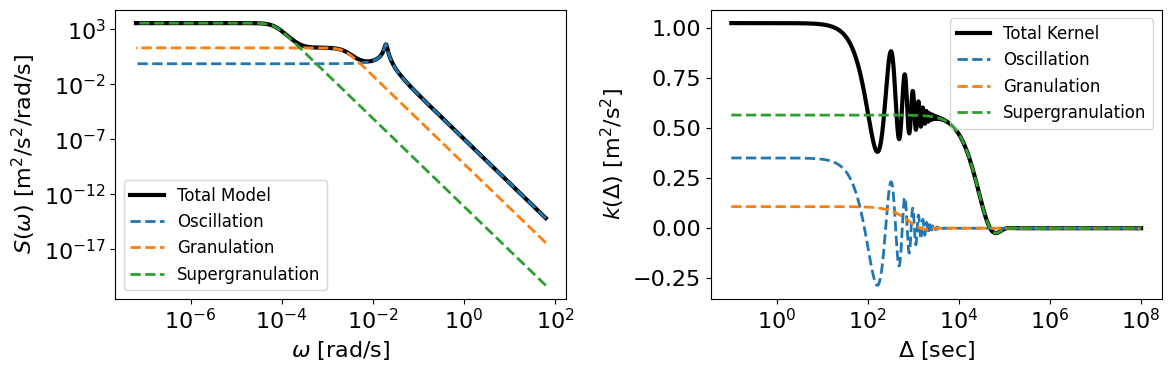

In [ ]:
## Plot the covariance function
fig, (pax, cax) = plt.subplots(1,2, figsize=(12,4))
dts = jnp.logspace(-1, 8, 1000) # sec (for covariance)
ws  = 2*jnp.pi/dts # rad/s (for PSD)
zeros = jnp.zeros_like(dts)
cov = kernel(zeros, dts)[0,:]
psd = kernel.psd(ws)
cax.plot(dts, cov, color='k', lw=3, label='Total Kernel')
pax.plot(ws, psd, color='k', lw=3, label='Total Model')
for k in ks:
    cov = k(zeros, dts)[0,:]
    cax.plot(dts, cov, lw=2, zorder=10, ls='--', label=k.name)
    pax.plot(ws, k.psd(ws), lw=2, zorder=10, ls='--', label=k.name)
cax.legend(loc='upper right', fontsize=12)
pax.legend(loc='lower left', fontsize=12)
cax.set_xscale('log')
pax.set(xscale='log', yscale='log')
cax.set(xlabel=r'$\Delta$ [sec]', ylabel=r'$k(\Delta)$ [m$^2$/s$^2$]');
pax.set(xlabel=r'$\omega$ [rad/s]', ylabel=r'$S(\omega)$ [m$^2$/s$^2$/rad/s]');
fig.tight_layout();

## Fitting a multicomponent model to data

First we'll need some data, which we can generate with `tinygp`.

In [ ]:
t_train = jnp.arange(100., 6 * 3600., 55.) # sec
yerr_train = 0.3 * jnp.ones_like(t_train) # m/s

kosc_tiny = tinygp.kernels.quasisep.SHO(sigma=sig_osc, omega=w_osc, quality=Q_osc)
kgran_tiny = tinygp.kernels.quasisep.SHO(sigma=sig_gran, omega=w_gran, quality=Q_gran)
ksgran_tiny = tinygp.kernels.quasisep.SHO(sigma=sig_sgran, omega=w_sgran, quality=Q_sgran)
gp_tiny = tinygp.GaussianProcess(kosc_tiny + kgran_tiny + ksgran_tiny, X=t_train, diag=yerr_train)

y_train = gp_tiny.sample(key)

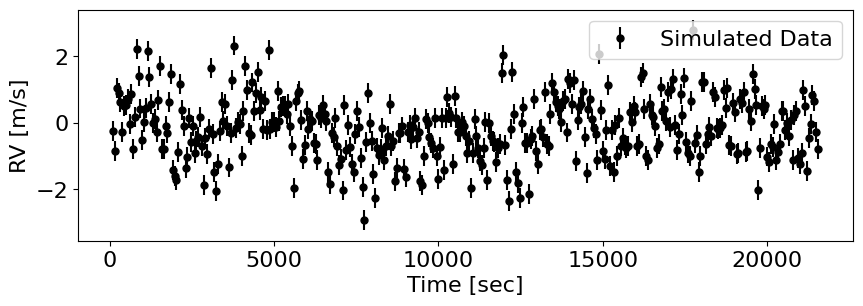

In [ ]:
fig, ax = plt.subplots(1,1, figsize=(10,3))
ax.errorbar(t_train, y_train, yerr=yerr_train, fmt='o', color='k', ms=5, label='Simulated Data')
ax.set(xlabel='Time [sec]', ylabel='RV [m/s]');
ax.legend(loc='upper right');

Next, let's fit our `smolgp` model as usual:

In [ ]:
gp_smol = smolgp.GaussianProcess(kernel=kernel, X=t_train, diag=yerr_train**2)

llh, condGP = gp_smol.condition(y_train)
print(f'Log-likelihood: {llh:.3f}')

# Predict at the training points
y_pred, yerr_pred = condGP.loc, jnp.sqrt(condGP.var)

# Predict at new test points
t_test = jnp.arange(t_train.min()-300, t_train.max()+300, 1)
mu_pred, var_pred = condGP.predict(t_test, return_var=True)

Log-likelihood: -582.828


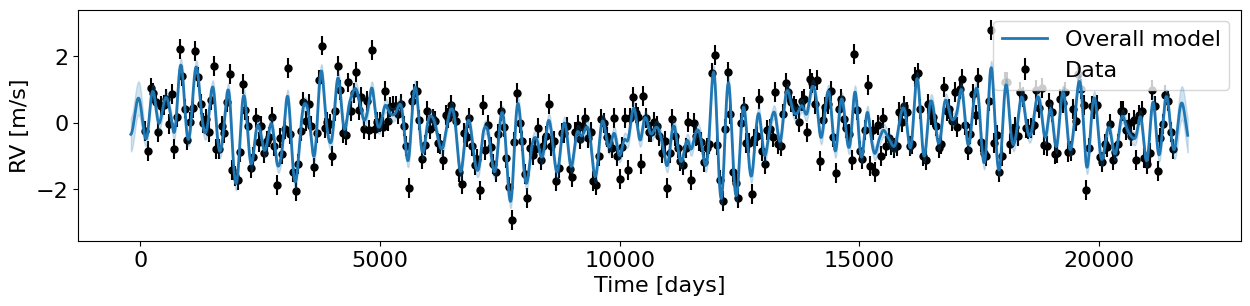

In [ ]:
fig, ax = plt.subplots(1,1, figsize=(15,3))
ax.errorbar(t_train, y_train, yerr=yerr_train, fmt='o', color='k', ms=5, label='Data')
ax.plot(t_test, mu_pred, color='C0', lw=2, label='Overall model', zorder=10)
ax.fill_between(t_test, mu_pred - jnp.sqrt(var_pred), mu_pred + jnp.sqrt(var_pred), zorder=10, color='C0', alpha=0.2)
ax.set(xlabel='Time [days]', ylabel='RV [m/s]');
ax.legend(loc='upper right');

## Decomposing into component posteriors

To get the individual component predictions, we can do the following:

In [ ]:
# 1. Conditioned component means/vars at the training points
cond_comps = condGP.get_all_component_means(return_var=True)

# 2. Predicted component means/vars at the test points
predStates = condGP.predict(t_test, return_full_state=True, return_var=True)

#   a) Overall (same as condGP.predict above)
mu_pred = predStates.loc
var_pred = predStates.variance

#   b) Per-component
pred_comps = predStates.get_all_components(return_var=True)

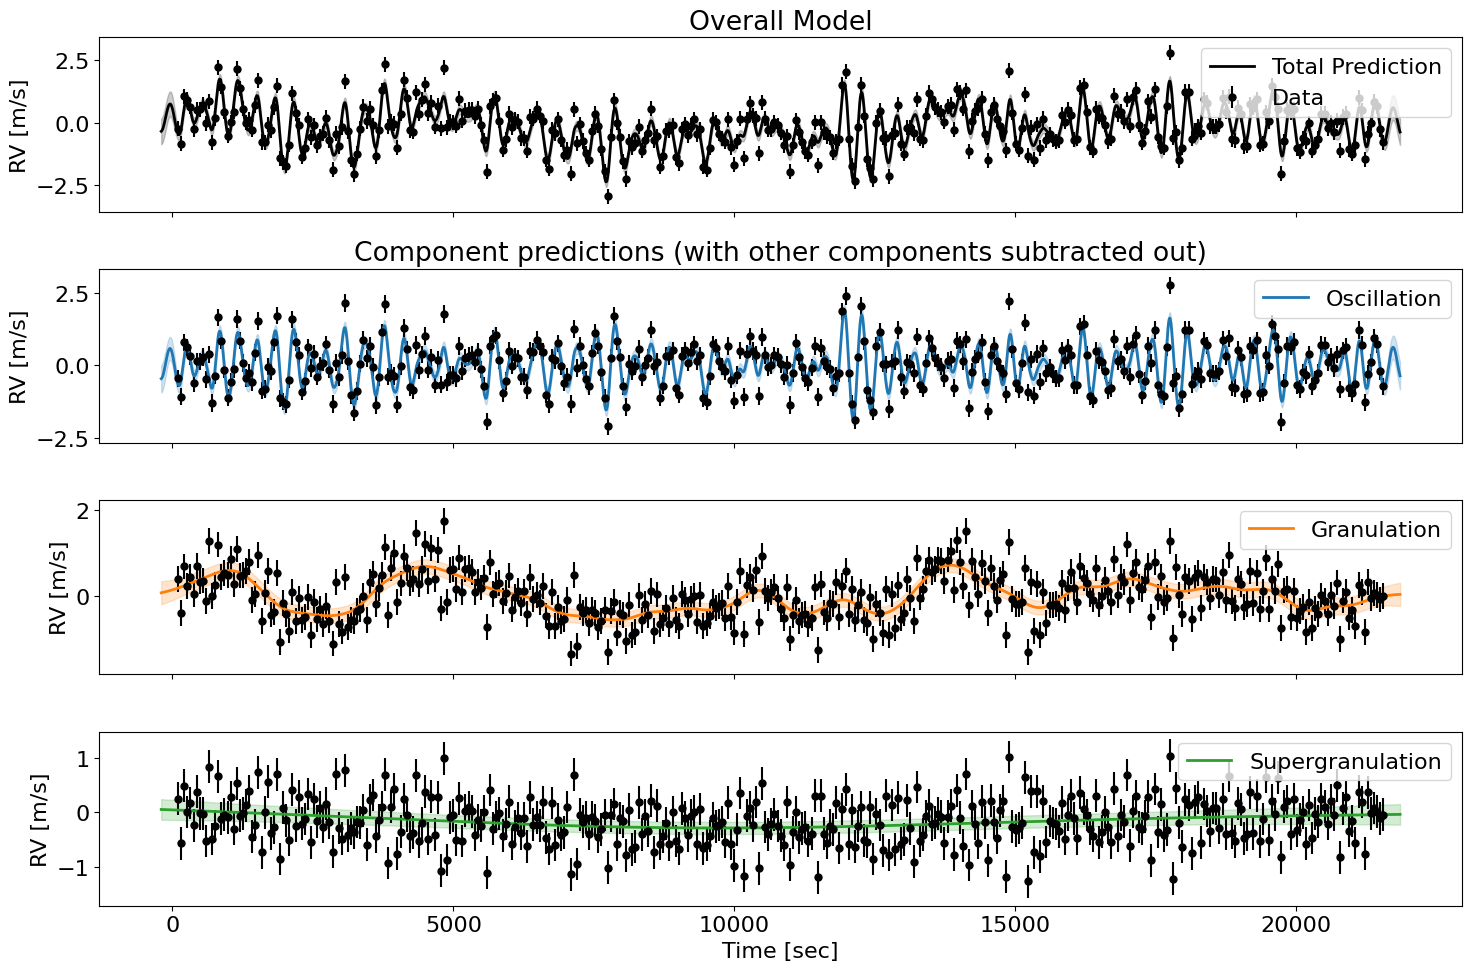

In [ ]:
fig, axes = plt.subplots(1 + len(pred_comps),1, figsize=(15, 2.5*(1 + len(pred_comps))), sharex=True)
axes[0].errorbar(t_train, y_train, yerr=yerr_train, fmt='o', color='k', ms=5, label='Data')
axes[0].plot(t_test, mu_pred, color='k', lw=2, label='Total Prediction')
axes[0].fill_between(t_test, mu_pred - jnp.sqrt(var_pred), mu_pred + jnp.sqrt(var_pred), color='k', alpha=0.2)
axes[0].legend(loc='upper right');
axes[0].set(ylabel='RV [m/s]', title='Overall Model');
axes[1].set_title('Component predictions (with other components subtracted out)');
for i, (comp_name, (comp_mu, comp_var)) in enumerate(pred_comps.items()):
    res_others = y_train - sum(cond_comps[c][0] for c in cond_comps if c != comp_name)
    axes[1 + i].errorbar(t_train, res_others, yerr=yerr_train, fmt='o', color='k', ms=5)
    axes[1 + i].plot(t_test, comp_mu, lw=2, label=comp_name, color=f'C{i}')
    axes[1 + i].fill_between(t_test, comp_mu - jnp.sqrt(comp_var), comp_mu + jnp.sqrt(comp_var), alpha=0.2, color=f'C{i}')
    axes[1 + i].legend(loc='upper right');
    axes[1 + i].set(ylabel='RV [m/s]');
axes[-1].set(xlabel='Time [sec]');
fig.tight_layout();

If we just wanted a specific named component, or say the total contribution from multiple named components, we could pass a list of names like so:

In [ ]:
names = ['Granulation', 'Supergranulation']
y_names, yvar_names = condGP.get_component_mean(names, return_var=True)
mu_names, var_names = predStates.get_component(names, return_var=True)

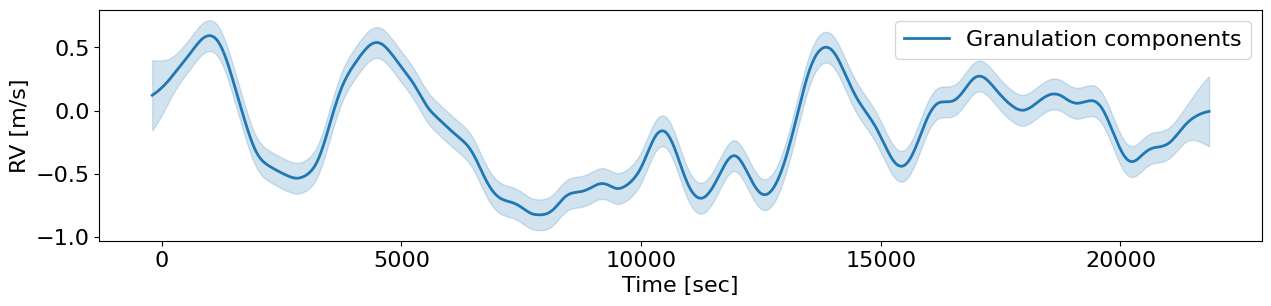

In [ ]:
fig, ax = plt.subplots(1,1, figsize=(15,3))
ax.plot(t_test, mu_names, color='C0', lw=2, label='Granulation components')
ax.fill_between(t_test, mu_names - jnp.sqrt(var_names), mu_names + jnp.sqrt(var_names), color='C0', alpha=0.2)
ax.legend(loc='upper right');
ax.set(xlabel='Time [sec]', ylabel='RV [m/s]');